### FIFA World Cup 2026 - Consumer Spending Accommodations and Food SARIMA Modeling
#### Forecasting restaurant and hotel consumer spending baselines for World Cup host and control (non-host) cities.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [11]:
# Reading in data
df = pd.read_csv('../data/processed/worldcup_city_seasonal_spending.csv', index_col='Date', parse_dates=True)
df.head()

,spend_all,spend_acf,cityname,stateabbrev,city_pop2019,season,host_status
Date,,,,,,,
2022-01-31,-0.1300,-0.1580,Los Angeles,CA,10039107,Winter,Host
2022-01-31,0.1810,0.0257,Chicago,IL,5150233,Winter,Non-Host
2022-01-31,-0.0201,-0.0351,Dallas,TX,2635516,Winter,Host
2022-01-31,0.0388,0.0112,Austin,TX,1273954,Winter,Non-Host
2022-01-31,-0.0339,-0.0717,Charlotte,NC,1110356,Winter,Non-Host


In [ ]:
# Testing SARIMA model on Atlanta to ensure pipline is working correctly

atl_df = df[df['cityname'] == 'Atlanta']
atl_spending = atl_df.spend_acf
print(atl_spending.head())
print()

# Running ADF test to check for stationarity
result = adfuller(atl_spending)
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')

# auto_arima model to find best parameters for SARIMA model
auto_model = auto_arima(
    atl_spending,
    seasonal=True,
    m=12,
    stepwise=True,
    suppress_warnings=True,
    information_criterion='aic'
)
print(auto_model.summary())
print()

# Fit SARIMA model with best parameters found by auto_arima
sarima_model = SARIMAX(
    atl_spending,
    order=(1, 0 ,0),
    seasonal_order=(0, 1, 1, 12))
model_fit = sarima_model.fit(disp=False) 

Date
2022-01-31    0.0437
2022-02-28    0.1190
2022-03-31    0.0663
2022-04-30    0.1240
2022-05-31    0.0842
Name: spend_acf, dtype: float64

ADF Statistic: -1.1454
p-value: 0.6966
                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                   53
Model:             SARIMAX(1, 0, 0)x(0, 1, [1], 12)   Log Likelihood                  84.091
Date:                              Wed, 01 Jul 2026   AIC                           -160.181
Time:                                      17:34:18   BIC                           -153.327
Sample:                                  01-31-2022   HQIC                          -157.685
                                       - 05-31-2026                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [39]:
# Generate forecasts for the next 12 months
forecast = model_fit.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()
print(forecast_mean)

2026-06-30    0.095816
2026-07-31    0.077420
2026-08-31    0.093854
2026-09-30    0.105951
2026-10-31    0.187978
2026-11-30    0.129014
2026-12-31    0.115324
2027-01-31    0.077246
2027-02-28    0.154805
2027-03-31    0.115433
2027-04-30    0.161531
2027-05-31    0.191522
Freq: ME, Name: predicted_mean, dtype: float64


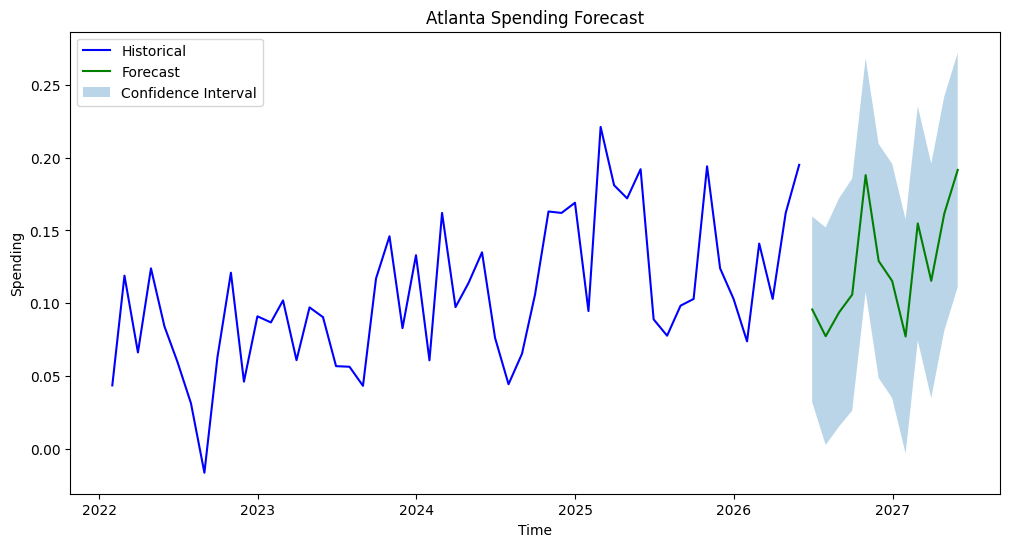

In [50]:
# Plotting Atlanta's forecasted spending trends

plt.figure(figsize=(12, 6))
plt.plot(atl_spending, label='Historical', color='blue')
plt.plot(forecast_mean, label='Forecast', color='green')
plt.fill_between(forecast_ci.index,
                 forecast_ci['lower spend_acf'],
                 forecast_ci['upper spend_acf'],
                 alpha=0.3,
                 label='Confidence Interval')
plt.title("Atlanta Spending Forecast")
plt.xlabel("Time")
plt.ylabel("Spending")
plt.legend()
plt.savefig('../outputs/figures/atlanta_forecast.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()